In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('egg_data.csv')

# Initial exploration
print(df.head())
print(df.info())
print(df.describe())

# Check for issues
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Notice: There's a duplicate 'SPEC' column called 'SPC' - drop it
df = df.drop('SPC', axis=1)

# Data quality issues to address:
# 1. One row has negative MASS (-132)
# 2. Some rows have VOL=0 and MASS=0
print("\nNegative values:")
print(df[df['MASS'] < 0])
print("\nZero mass/volume:")
print(df[(df['MASS'] == 0) | (df['VOL'] == 0)].shape)

     SPEC  VOL  MASS  AGE  SPOT      NEST  TEMP     SPC
0  Wyvern  398   665  446    10   Coastal  38.7  Wyvern
1   Hydra   13     7  477     8  Volcanic  82.9   Hydra
2   Hydra   61    32   74     8   Coastal  29.0   Hydra
3   Hydra   44    68  207     9    Forest  21.8   Hydra
4  Dragon   99   120   61     2  Volcanic  70.9  Dragon
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPEC    500 non-null    object 
 1   VOL     500 non-null    int64  
 2   MASS    500 non-null    int64  
 3   AGE     500 non-null    int64  
 4   SPOT    500 non-null    int64  
 5   NEST    500 non-null    object 
 6   TEMP    500 non-null    float64
 7   SPC     500 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 31.4+ KB
None
               VOL         MASS         AGE        SPOT        TEMP
count   500.000000   500.000000  500.000000  500.00000

In [ ]:
# Class distribution
print("\nClass Distribution:")
print(df['SPEC'].value_counts())
print("\nClass Proportions:")
print(df['SPEC'].value_counts(normalize=True))

# Statistics by species
print("\nStatistics by Species:")
print(df.groupby('SPEC').describe())

# Statistics for categorical variable
print("\nNest Type Distribution:")
print(pd.crosstab(df['SPEC'], df['NEST'], normalize='index'))


Class Distribution:
SPEC
Hydra     260
Wyvern    173
Dragon     67
Name: count, dtype: int64

Class Proportions:
SPEC
Hydra     0.520
Wyvern    0.346
Dragon    0.134
Name: proportion, dtype: float64

Statistics by Species:
          VOL                                                            \
        count        mean         std  min   25%    50%     75%     max   
SPEC                                                                      
Dragon   67.0  274.223881  302.588420  0.0  20.5  144.0  457.00  1299.0   
Hydra   260.0   40.088462   43.393190  0.0   8.0   24.5   57.25   207.0   
Wyvern  173.0  100.000000  114.955502  0.0  16.0   52.0  150.00   465.0   

         MASS              ...  SPOT         TEMP                              \
        count        mean  ...   75%   max  count       mean        std   min   
SPEC                       ...                                                  
Dragon   67.0  754.791045  ...   4.0   5.0   67.0  45.973134  23.626837  12.0   
H

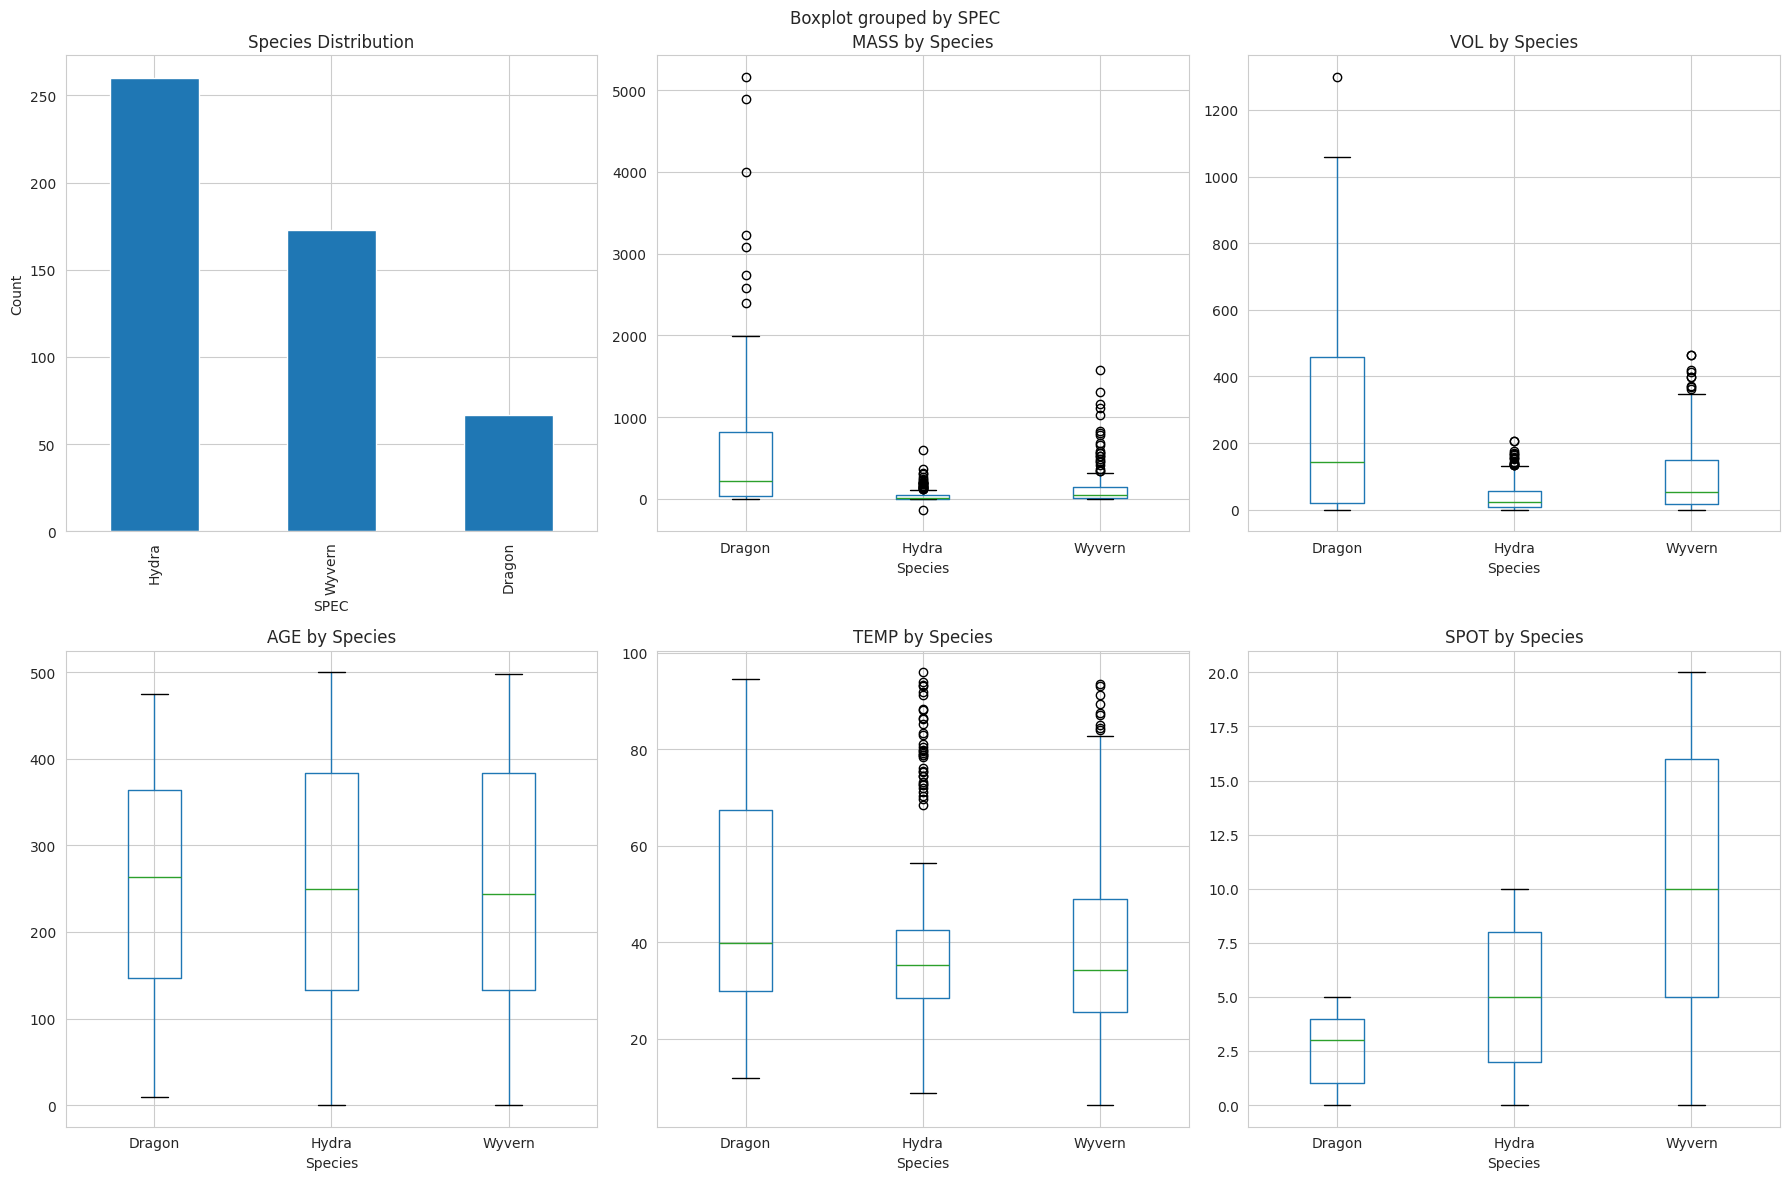

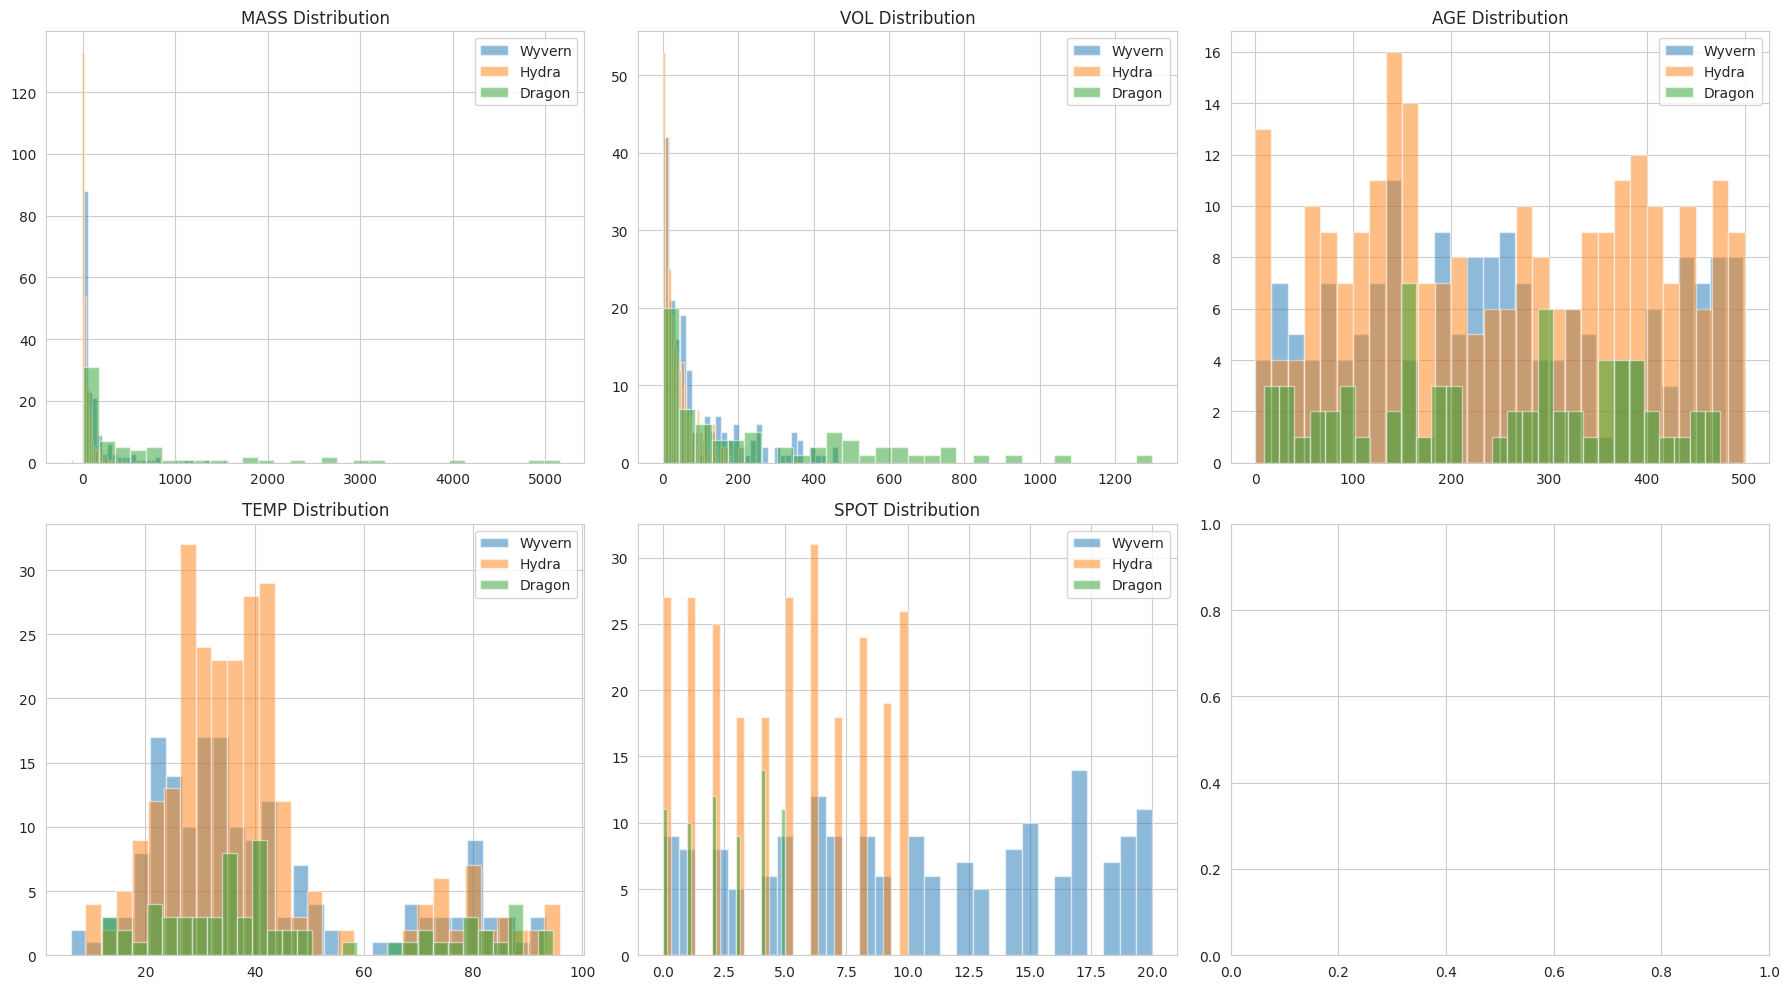

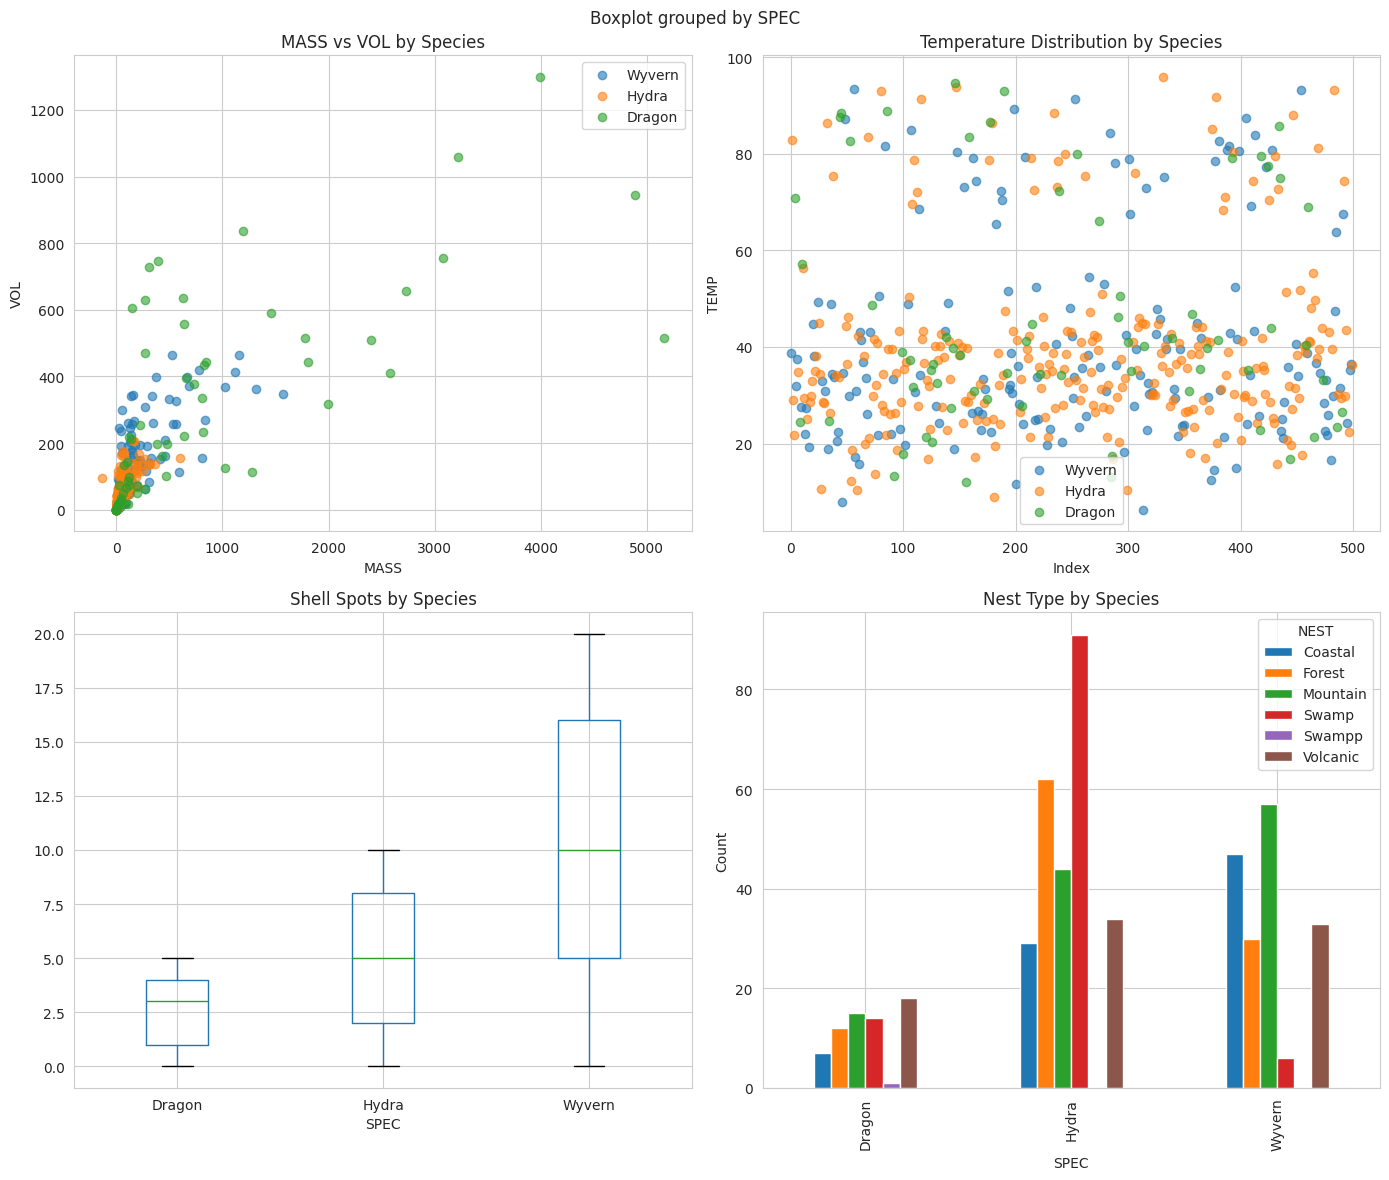

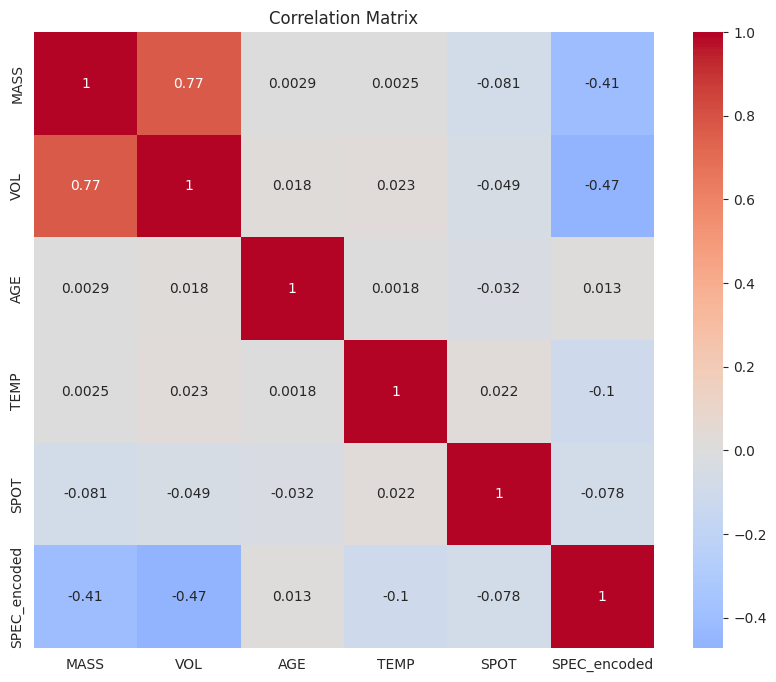

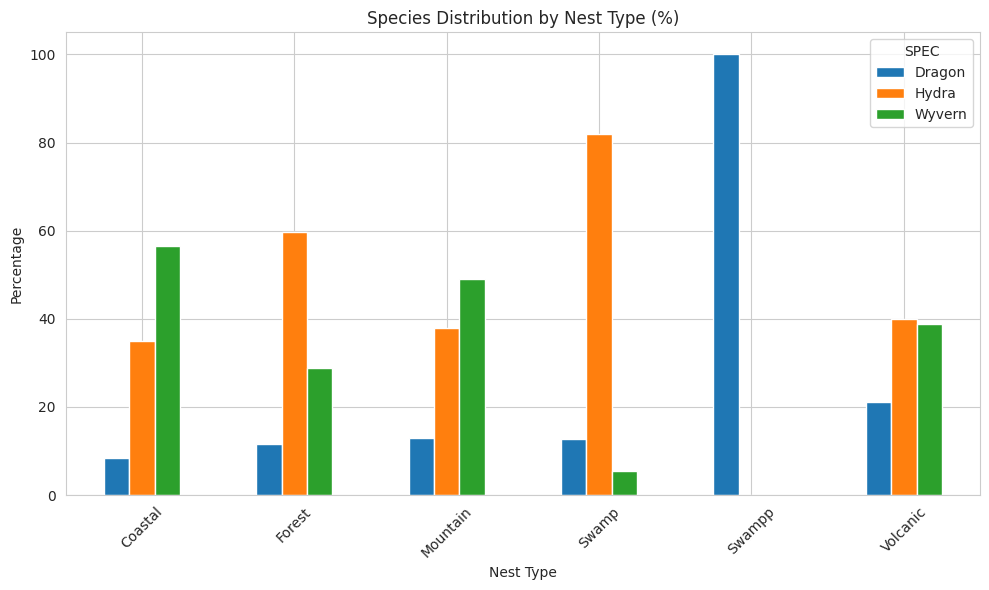

In [ ]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 1. Class distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Species distribution
df['SPEC'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Species Distribution')
axes[0,0].set_ylabel('Count')

# 2. Numerical features by species - Boxplots
for idx, col in enumerate(['MASS', 'VOL', 'AGE', 'TEMP', 'SPOT']):
    row = (idx + 1) // 3
    col_idx = (idx + 1) % 3
    df.boxplot(column=col, by='SPEC', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} by Species')
    axes[row, col_idx].set_xlabel('Species')

plt.tight_layout()
plt.savefig('boxplots_by_species.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
numerical_cols = ['MASS', 'VOL', 'AGE', 'TEMP', 'SPOT']

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    for species in df['SPEC'].unique():
        data = df[df['SPEC'] == species][col]
        axes[row, col_idx].hist(data, alpha=0.5, label=species, bins=30)
    axes[row, col_idx].set_title(f'{col} Distribution')
    axes[row, col_idx].legend()

plt.tight_layout()
plt.savefig('distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Scatter plots for key relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# MASS vs VOL
for species in df['SPEC'].unique():
    subset = df[df['SPEC'] == species]
    axes[0,0].scatter(subset['MASS'], subset['VOL'], alpha=0.6, label=species)
axes[0,0].set_xlabel('MASS')
axes[0,0].set_ylabel('VOL')
axes[0,0].set_title('MASS vs VOL by Species')
axes[0,0].legend()

# TEMP vs Species
for species in df['SPEC'].unique():
    subset = df[df['SPEC'] == species]
    axes[0,1].scatter(subset.index, subset['TEMP'], alpha=0.6, label=species)
axes[0,1].set_xlabel('Index')
axes[0,1].set_ylabel('TEMP')
axes[0,1].set_title('Temperature Distribution by Species')
axes[0,1].legend()

# SPOT vs Species
df.boxplot(column='SPOT', by='SPEC', ax=axes[1,0])
axes[1,0].set_title('Shell Spots by Species')

# NEST type distribution
pd.crosstab(df['SPEC'], df['NEST']).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Nest Type by Species')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('relationships.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Correlation matrix
plt.figure(figsize=(10, 8))
# Encode SPEC for correlation
df_temp = df.copy()
df_temp['SPEC_encoded'] = df_temp['SPEC'].map({'Dragon': 0, 'Wyvern': 1, 'Hydra': 2})
corr_cols = ['MASS', 'VOL', 'AGE', 'TEMP', 'SPOT', 'SPEC_encoded']
correlation = df_temp[corr_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Nest type visualization
fig, ax = plt.subplots(figsize=(10, 6))
nest_species = pd.crosstab(df['NEST'], df['SPEC'], normalize='index') * 100
nest_species.plot(kind='bar', ax=ax, stacked=False)
ax.set_title('Species Distribution by Nest Type (%)')
ax.set_ylabel('Percentage')
ax.set_xlabel('Nest Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nest_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Feature engineering

In [ ]:
# Clean data first
df_clean = df.copy()

# Remove/fix problematic rows
df_clean = df_clean[df_clean['MASS'] >= 0]  # Remove negative mass

# Decision on zero values - document your choice:
# Option 1: Remove them
# df_clean = df_clean[(df_clean['MASS'] > 0) & (df_clean['VOL'] > 0)]

# Option 2: Keep them (they might be valid very small/new eggs)
# We'll keep them for now but note this decision

print(f"Dataset size after cleaning: {df_clean.shape[0]} rows")

Dataset size after cleaning: 499 rows


In [ ]:
#Feature engineering begin
# Create new features based on domain knowledge

# 1. Density (MASS/VOL) - physical property that might be species-specific
df_clean['DENSITY'] = np.where(df_clean['VOL'] > 0,
                                df_clean['MASS'] / df_clean['VOL'],
                                0)

# 2. Log transformations for skewed features
df_clean['LOG_MASS'] = np.log1p(df_clean['MASS'])  # log1p handles zeros
df_clean['LOG_VOL'] = np.log1p(df_clean['VOL'])

# 3. Temperature categories (based on exploration)
df_clean['TEMP_CATEGORY'] = pd.cut(df_clean['TEMP'],
                                    bins=[0, 30, 60, 100],
                                    labels=['Low', 'Medium', 'High'])

# 4. Polynomial features for MASS and VOL (capture non-linear relationships)
df_clean['MASS_SQUARED'] = df_clean['MASS'] ** 2
df_clean['VOL_SQUARED'] = df_clean['VOL'] ** 2

# 5. Interaction term: TEMP * (Volcanic nest indicator)
df_clean['TEMP_VOLCANIC'] = df_clean['TEMP'] * (df_clean['NEST'] == 'Volcanic').astype(int)

# 6. Size category
df_clean['SIZE_CATEGORY'] = pd.cut(df_clean['MASS'],
                                    bins=[-1, 50, 200, 5000],
                                    labels=['Small', 'Medium', 'Large'])

# View engineered features
print("\nEngineered Features:")
print(df_clean[['DENSITY', 'LOG_MASS', 'LOG_VOL', 'TEMP_VOLCANIC']].describe())


Engineered Features:
          DENSITY    LOG_MASS     LOG_VOL  TEMP_VOLCANIC
count  499.000000  499.000000  499.000000     499.000000
mean     1.264315    3.453707    3.495090      13.650100
std      1.289867    1.857055    1.583842      30.325725
min      0.000000    0.000000    0.000000       0.000000
25%      0.490000    2.079442    2.484907       0.000000
50%      0.921875    3.465736    3.637586       0.000000
75%      1.634852    4.714015    4.610145       0.000000
max     11.437500    8.549273    7.170120      95.900000



Feature Importance (ANOVA F-test):
         Feature     F-Score
3           SPOT  110.417650
1            VOL   82.835148
0           MASS   65.507789
7       LOG_MASS   56.155528
6        DENSITY   44.485081
8        LOG_VOL   29.689325
5   NEST_encoded    6.431951
9  TEMP_VOLCANIC    3.978154
4           TEMP    2.866041
2            AGE    0.092972

Feature Importance (Mutual Information):
         Feature  MI-Score
3           SPOT  0.294329
1            VOL  0.188354
8        LOG_VOL  0.176843
0           MASS  0.160703
7       LOG_MASS  0.146843
5   NEST_encoded  0.114006
6        DENSITY  0.074461
2            AGE  0.004612
4           TEMP  0.000000
9  TEMP_VOLCANIC  0.000000


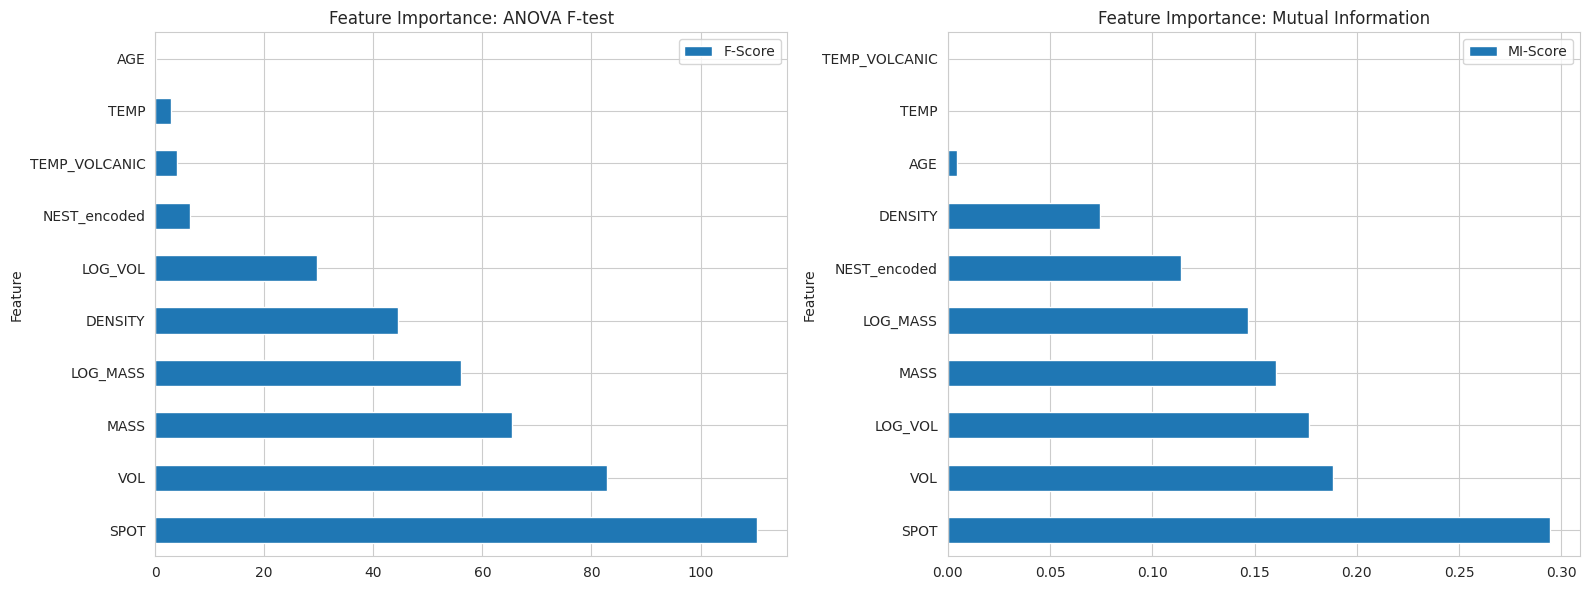

In [ ]:
#Feature selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Prepare data for feature selection
X = df_clean.copy()
y = X['SPEC']
X = X.drop(['SPEC'], axis=1)

# Encode categorical variables
le_nest = LabelEncoder()
X['NEST_encoded'] = le_nest.fit_transform(X['NEST'])

# Select numerical features for testing
numerical_features = ['MASS', 'VOL', 'AGE', 'SPOT', 'TEMP', 'NEST_encoded',
                     'DENSITY', 'LOG_MASS', 'LOG_VOL', 'TEMP_VOLCANIC']

X_numerical = X[numerical_features].fillna(0)  # Handle any NaN from density calculation

# Encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# 1. Univariate Feature Selection (ANOVA F-test)
selector_f = SelectKBest(score_func=f_classif, k='all')
selector_f.fit(X_numerical, y_encoded)

# Get scores
feature_scores_f = pd.DataFrame({
    'Feature': numerical_features,
    'F-Score': selector_f.scores_
}).sort_values('F-Score', ascending=False)

print("\nFeature Importance (ANOVA F-test):")
print(feature_scores_f)

# 2. Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
selector_mi.fit(X_numerical, y_encoded)

feature_scores_mi = pd.DataFrame({
    'Feature': numerical_features,
    'MI-Score': selector_mi.scores_
}).sort_values('MI-Score', ascending=False)

print("\nFeature Importance (Mutual Information):")
print(feature_scores_mi)

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feature_scores_f.plot(x='Feature', y='F-Score', kind='barh', ax=axes[0])
axes[0].set_title('Feature Importance: ANOVA F-test')

feature_scores_mi.plot(x='Feature', y='MI-Score', kind='barh', ax=axes[1])
axes[1].set_title('Feature Importance: Mutual Information')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Check VIF for multicollinearity
vif_data = pd.DataFrame()
vif_data["Feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(X_numerical.values, i)
                   for i in range(len(numerical_features))]

print("\nVariance Inflation Factors:")
print(vif_data.sort_values('VIF', ascending=False))
print("\nNote: VIF > 10 indicates high multicollinearity")



Variance Inflation Factors:
         Feature        VIF
7       LOG_MASS  81.055347
8        LOG_VOL  66.386012
4           TEMP  18.202248
5   NEST_encoded   8.972162
6        DENSITY   8.868436
1            VOL   7.009373
0           MASS   4.963801
9  TEMP_VOLCANIC   4.087478
2            AGE   3.773669
3           SPOT   2.427002

Note: VIF > 10 indicates high multicollinearity


In [ ]:
# Model construction

In [ ]:
#Data splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Prepare final dataset
df_model = df_clean.copy()

# Define features to use
selected_features = ['LOG_MASS', 'LOG_VOL', 'TEMP', 'SPOT', 'NEST', 'TEMP_VOLCANIC']

X = df_model[selected_features]
y = df_model['SPEC']

# Split: 60% train, 20% validation, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25,
                                                    random_state=42, stratify=y_temp)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Check class distribution
print("\nClass distribution in sets:")
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Training set: 299 samples
Validation set: 100 samples
Test set: 100 samples

Class distribution in sets:
Train: SPEC
Hydra     0.518395
Wyvern    0.344482
Dragon    0.137124
Name: proportion, dtype: float64
Val: SPEC
Hydra     0.52
Wyvern    0.35
Dragon    0.13
Name: proportion, dtype: float64
Test: SPEC
Hydra     0.52
Wyvern    0.35
Dragon    0.13
Name: proportion, dtype: float64


In [ ]:
# Preprocessing

In [ ]:
# Define preprocessing
numerical_features = ['LOG_MASS', 'LOG_VOL', 'TEMP', 'SPOT', 'TEMP_VOLCANIC']
categorical_features = ['NEST']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

# View transformed feature names
preprocessor.fit(X_train)
feature_names = (numerical_features +
                 list(preprocessor.named_transformers_['cat'].get_feature_names_out(['NEST'])))
print(f"\nTransformed features ({len(feature_names)}):", feature_names)


Transformed features (10): ['LOG_MASS', 'LOG_VOL', 'TEMP', 'SPOT', 'TEMP_VOLCANIC', 'NEST_Forest', 'NEST_Mountain', 'NEST_Swamp', 'NEST_Swampp', 'NEST_Volcanic']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C= 0.001 -> Validation Accuracy: 0.5200
C= 0.010 -> Validation Accuracy: 0.7200


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C= 0.100 -> Validation Accuracy: 0.8000
C= 1.000 -> Validation Accuracy: 0.7700
C=10.000 -> Validation Accuracy: 0.7600


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C=100.000 -> Validation Accuracy: 0.7700


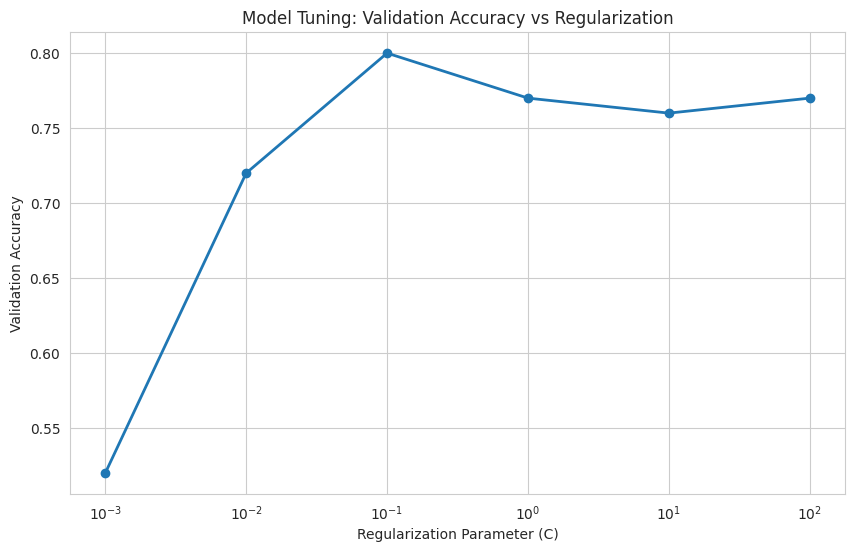


Best C value: 0.1 with validation accuracy: 0.8000


In [ ]:
#Tranining and tuning
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Try different regularization strengths
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
val_scores = []

for C in C_values:
    # Create pipeline
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(C=C, max_iter=1000,
                                         multi_class='multinomial',
                                         random_state=42))
    ])

    # Train
    model.fit(X_train, y_train)

    # Validate
    val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)
    val_scores.append(val_acc)

    print(f"C={C:6.3f} -> Validation Accuracy: {val_acc:.4f}")

# Plot validation curve
plt.figure(figsize=(10, 6))
plt.semilogx(C_values, val_scores, marker='o', linewidth=2)
plt.xlabel('Regularization Parameter (C)')
plt.ylabel('Validation Accuracy')
plt.title('Model Tuning: Validation Accuracy vs Regularization')
plt.grid(True)
plt.savefig('validation_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Select best C
best_C = C_values[np.argmax(val_scores)]
print(f"\nBest C value: {best_C} with validation accuracy: {max(val_scores):.4f}")

In [ ]:
#Final model training
# Train final model with best hyperparameters
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=best_C, max_iter=1000,
                                     multi_class='multinomial',
                                     random_state=42))
])

final_model.fit(X_train, y_train)

# Predictions on all sets
train_pred = final_model.predict(X_train)
val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

# Accuracies
train_acc = accuracy_score(y_train, train_pred)
val_acc = accuracy_score(y_val, val_pred)
test_acc = accuracy_score(y_test, test_pred)

print("\n" + "-"*50)
print("Final model performance")
print("-"*50)
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print("-"*50)


--------------------------------------------------
Final model performance
--------------------------------------------------
Training Accuracy:   0.7492
Validation Accuracy: 0.8000
Test Accuracy:       0.7200
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
#Model evaluation

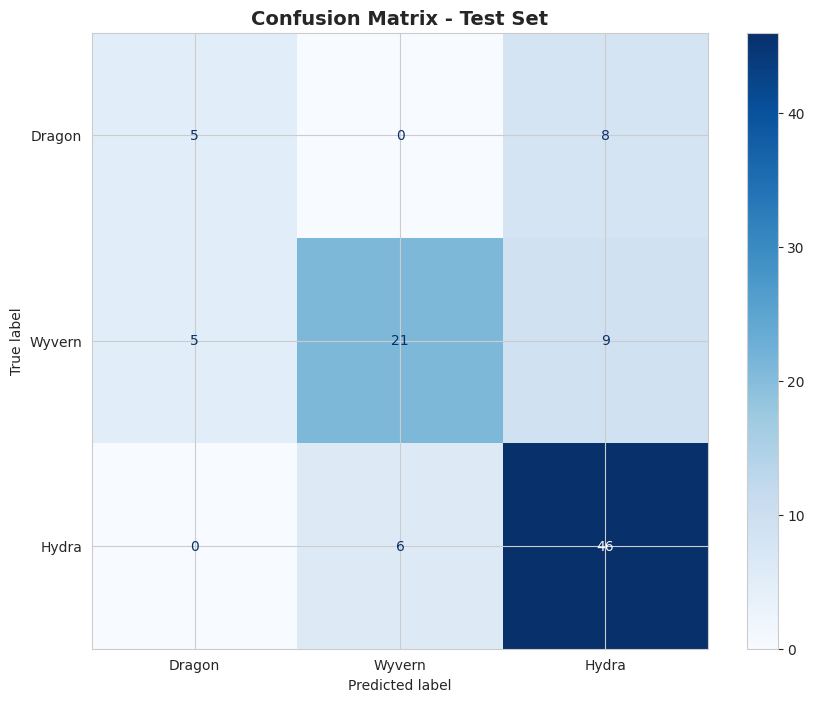

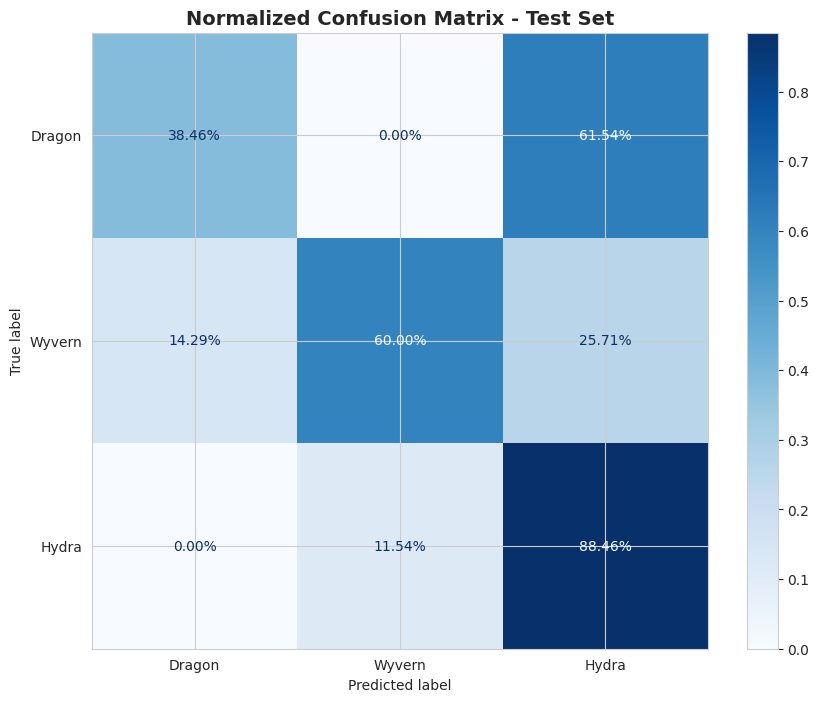

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for test set
cm = confusion_matrix(y_test, test_pred, labels=['Dragon', 'Wyvern', 'Hydra'])

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Dragon', 'Wyvern', 'Hydra'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = confusion_matrix(y_test, test_pred,
                                 labels=['Dragon', 'Wyvern', 'Hydra'],
                                 normalize='true')

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                               display_labels=['Dragon', 'Wyvern', 'Hydra'])
disp.plot(ax=ax, cmap='Blues', values_format='.2%')
plt.title('Normalized Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix_normalized.png', dpi=300, bbox_inches='tight')
plt.show()


------------------------------------------------------------
Classification report - Test set
------------------------------------------------------------
              precision    recall  f1-score   support

      Dragon       0.50      0.38      0.43        13
      Wyvern       0.73      0.88      0.80        52
       Hydra       0.78      0.60      0.68        35

    accuracy                           0.72       100
   macro avg       0.67      0.62      0.64       100
weighted avg       0.72      0.72      0.71       100


Per-Class Metrics:
Species  Precision   Recall  F1-Score  Support
 Dragon   0.500000 0.384615  0.434783       13
 Wyvern   0.777778 0.600000  0.677419       35
  Hydra   0.730159 0.884615  0.800000       52


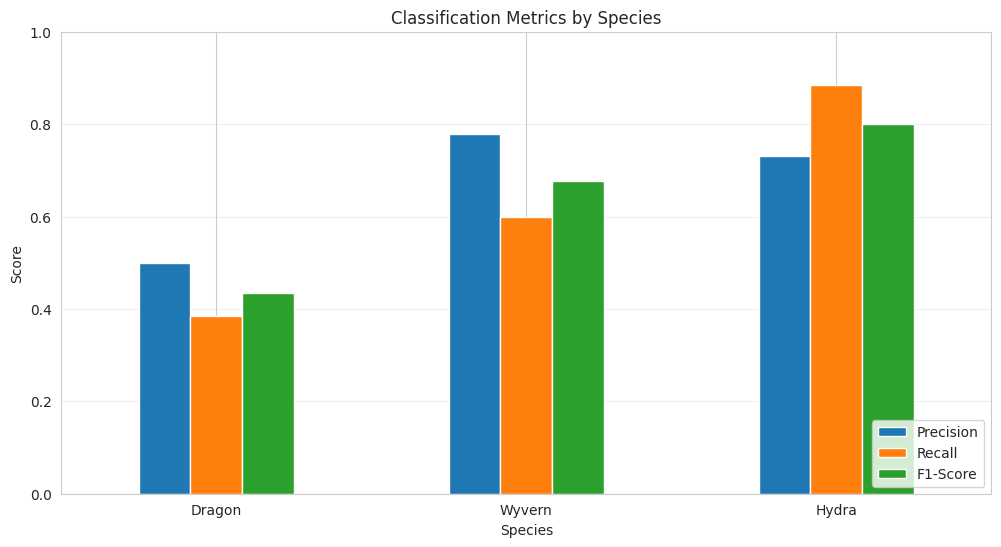

In [ ]:
#classification matrix
from sklearn.metrics import classification_report, precision_recall_fscore_support

# Detailed classification report
print("\n" + "-"*60)
print("Classification report - Test set")
print("-"*60)
print(classification_report(y_test, test_pred,
                           target_names=['Dragon', 'Wyvern', 'Hydra']))

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, test_pred, labels=['Dragon', 'Wyvern', 'Hydra']
)

metrics_df = pd.DataFrame({
    'Species': ['Dragon', 'Wyvern', 'Hydra'],
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print("\nPer-Class Metrics:")
print(metrics_df.to_string(index=False))

# Visualize metrics
metrics_df_plot = metrics_df.set_index('Species')[['Precision', 'Recall', 'F1-Score']]
metrics_df_plot.plot(kind='bar', figsize=(12, 6))
plt.title('Classification Metrics by Species')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.savefig('metrics_by_species.png', dpi=300, bbox_inches='tight')
plt.show()

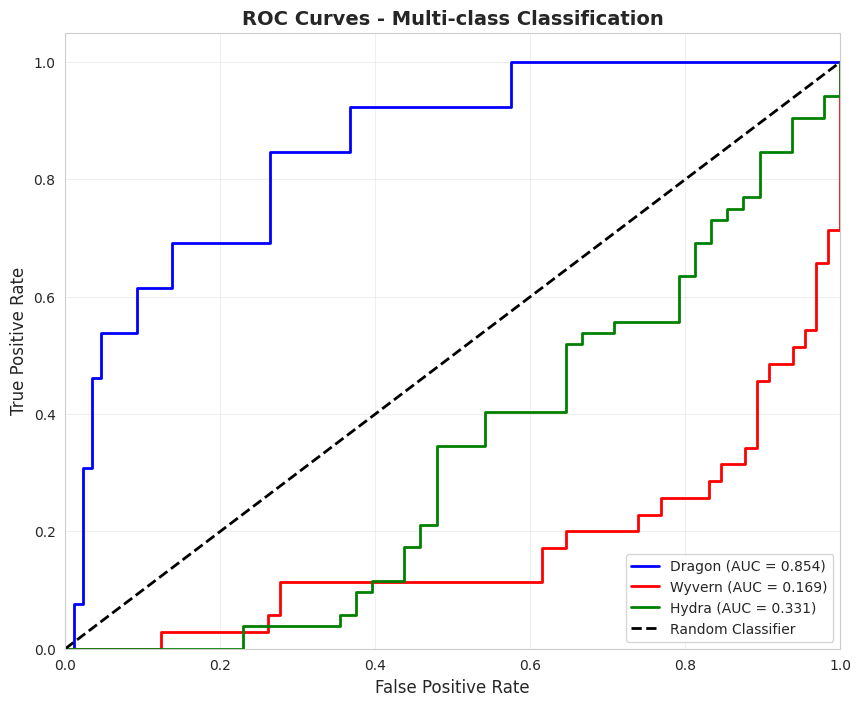


ROC AUC Scores:
Dragon: 0.8541
Wyvern: 0.1688
Hydra: 0.3313


In [ ]:
#ROC Curves (Multi class)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get probability predictions
y_test_proba = final_model.predict_proba(X_test)

# Binarize the output
y_test_bin = label_binarize(y_test, classes=['Dragon', 'Wyvern', 'Hydra'])
n_classes = 3

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, species in enumerate(['Dragon', 'Wyvern', 'Hydra']):
    fpr[i] = []
    tpr[i] = []
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
species_names = ['Dragon', 'Wyvern', 'Hydra']

for i, color, species in zip(range(n_classes), colors, species_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{species} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Multi-class Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nROC AUC Scores:")
for i, species in enumerate(species_names):
    print(f"{species}: {roc_auc[i]:.4f}")

In [ ]:
#Error analysis
# Analyze misclassifications
test_results = X_test.copy()
test_results['True_Species'] = y_test.values
test_results['Predicted_Species'] = test_pred
test_results['Correct'] = test_results['True_Species'] == test_results['Predicted_Species']

# Get misclassified samples
misclassified = test_results[~test_results['Correct']]

print(f"\nMisclassified Samples: {len(misclassified)} out of {len(test_results)}")
print("\nMisclassification Breakdown:")
print(pd.crosstab(misclassified['True_Species'],
                  misclassified['Predicted_Species'],
                  rownames=['True'], colnames=['Predicted']))

# Examine some misclassified cases
print("\nSample Misclassifications:")
print(misclassified[['True_Species', 'Predicted_Species',
                     'TEMP', 'LOG_MASS', 'NEST']].head(10))


Misclassified Samples: 28 out of 100

Misclassification Breakdown:
Predicted  Dragon  Hydra  Wyvern
True                            
Dragon          0      8       0
Hydra           0      0       6
Wyvern          5      9       0

Sample Misclassifications:
    True_Species Predicted_Species  TEMP  LOG_MASS      NEST
157        Hydra            Wyvern  39.7  4.875197  Mountain
269        Hydra            Wyvern  28.0  3.465736  Mountain
361       Wyvern             Hydra  45.0  4.343805  Mountain
428       Wyvern            Dragon  80.8  4.672829  Volcanic
266        Hydra            Wyvern  47.2  2.639057  Mountain
451       Wyvern             Hydra  33.9  2.708050     Swamp
467       Wyvern            Dragon  36.6  6.933423  Mountain
88         Hydra            Wyvern  26.2  2.397895   Coastal
392       Dragon             Hydra  79.1  3.367296  Volcanic
426        Hydra            Wyvern  28.5  2.564949  Mountain


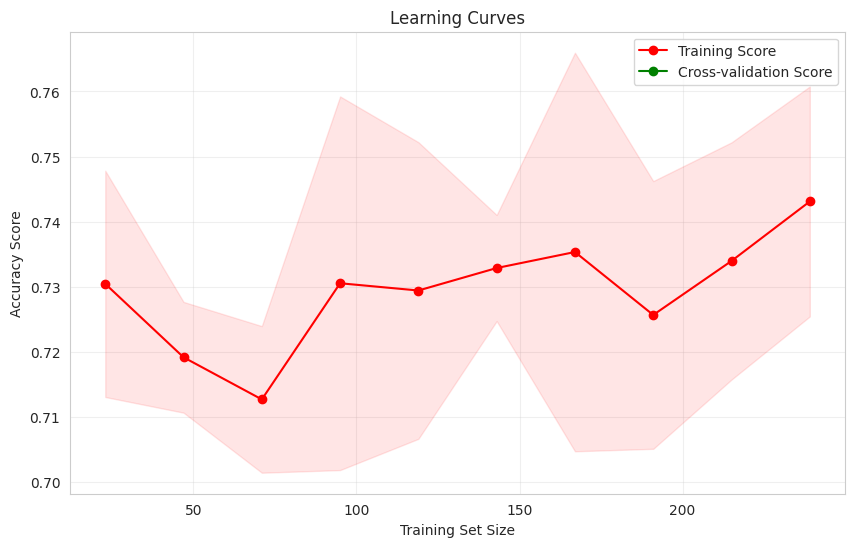

In [ ]:
#Learning curves
from sklearn.model_selection import learning_curve

# Compute learning curves
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-validation Score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.1, color='r')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.1, color='g')

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Interpertation



------------------------------------------------------------
Model coefficients
------------------------------------------------------------
                      Dragon    Wyvern     Hydra
num__LOG_MASS       0.455955 -0.599277  0.143322
num__LOG_VOL        0.086230  0.109186 -0.195416
num__TEMP          -0.029868  0.068768 -0.038900
num__SPOT          -0.780364 -0.061995  0.842359
num__TEMP_VOLCANIC  0.103320 -0.051178 -0.052142
cat__NEST_Forest   -0.209284  0.365373 -0.156089
cat__NEST_Mountain  0.020823 -0.184782  0.163960
cat__NEST_Swamp     0.083886  0.672158 -0.756044
cat__NEST_Swampp    0.040289 -0.012297 -0.027992
cat__NEST_Volcanic  0.036030 -0.061462  0.025432


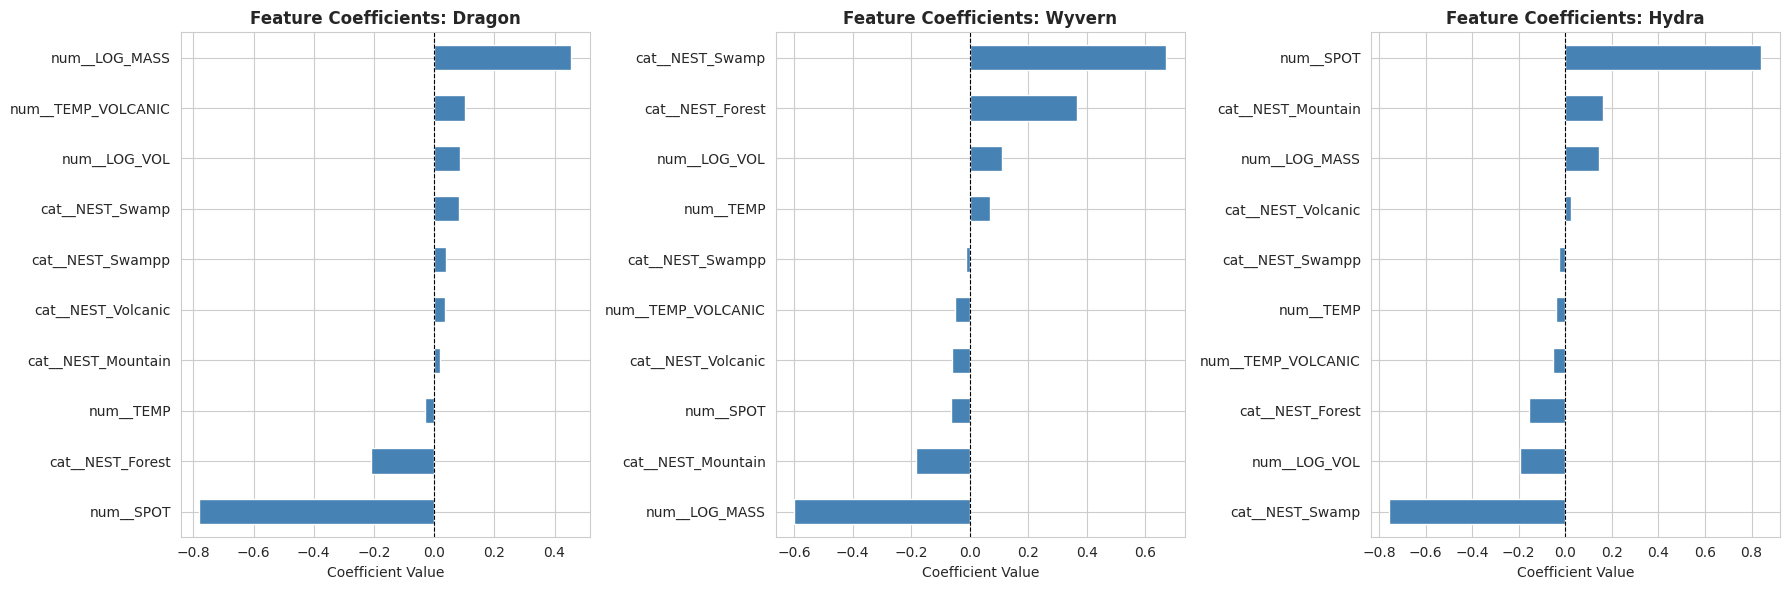

In [ ]:
#Coefficient analysis
# Extract coefficients from the trained model
classifier = final_model.named_steps['classifier']
coefficients = classifier.coef_
intercepts = classifier.intercept_

# Get feature names from preprocessor
feature_names_transformed = final_model.named_steps['preprocessor'].get_feature_names_out()

# Create coefficient dataframe
coef_df = pd.DataFrame(
    coefficients.T,
    columns=['Dragon', 'Wyvern', 'Hydra'],
    index=feature_names_transformed
)

print("\n" + "-"*60)
print("Model coefficients")
print("-"*60)
print(coef_df)

# Visualize coefficients
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, species in enumerate(['Dragon', 'Wyvern', 'Hydra']):
    coef_sorted = coef_df[species].sort_values()
    coef_sorted.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Feature Coefficients: {species}', fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    axes[idx].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()


------------------------------------------------------------
Feature importance ranking
------------------------------------------------------------
                    Mean_Abs_Importance    Dragon    Wyvern     Hydra
num__SPOT                      0.561573 -0.780364 -0.061995  0.842359
cat__NEST_Swamp                0.504030  0.083886  0.672158 -0.756044
num__LOG_MASS                  0.399518  0.455955 -0.599277  0.143322
cat__NEST_Forest               0.243582 -0.209284  0.365373 -0.156089
num__LOG_VOL                   0.130277  0.086230  0.109186 -0.195416
cat__NEST_Mountain             0.123188  0.020823 -0.184782  0.163960
num__TEMP_VOLCANIC             0.068880  0.103320 -0.051178 -0.052142
num__TEMP                      0.045845 -0.029868  0.068768 -0.038900
cat__NEST_Volcanic             0.040975  0.036030 -0.061462  0.025432
cat__NEST_Swampp               0.026859  0.040289 -0.012297 -0.027992


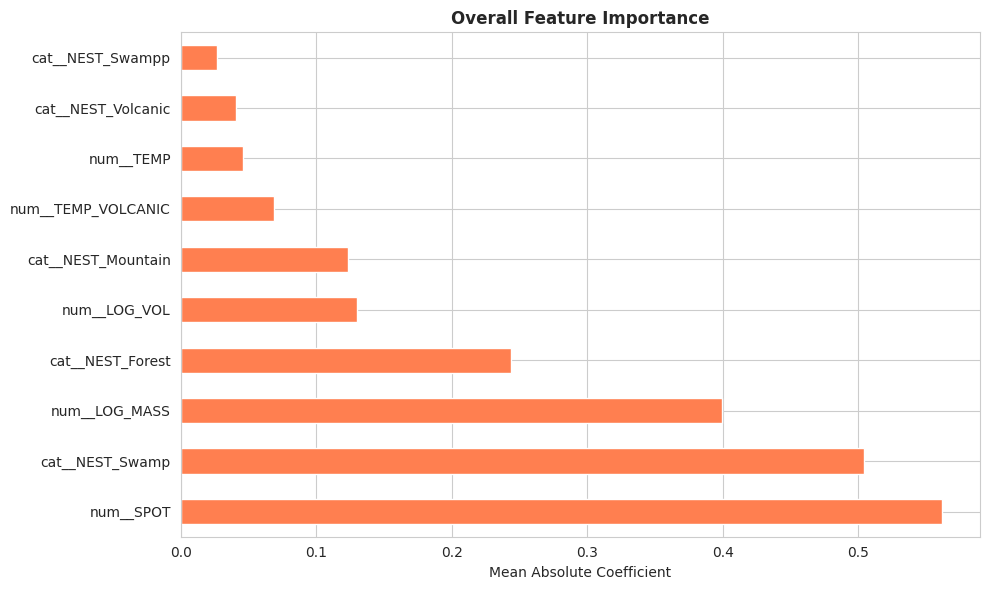

In [ ]:
#Feature importance ranking
# Calculate absolute mean importance across all classes
coef_df['Mean_Abs_Importance'] = coef_df.abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values('Mean_Abs_Importance', ascending=False)

print("\n" + "-"*60)
print("Feature importance ranking")
print("-"*60)
print(coef_df_sorted[['Mean_Abs_Importance', 'Dragon', 'Wyvern', 'Hydra']])

# Visualize overall importance
plt.figure(figsize=(10, 6))
coef_df_sorted['Mean_Abs_Importance'].plot(kind='barh', color='coral')
plt.xlabel('Mean Absolute Coefficient')
plt.title('Overall Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig('overall_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Interpertation by species
# Most important features for each species
print("\n" + "-"*60)
print("Top 5 features by species")
print("-"*60)

for species in ['Dragon', 'Wyvern', 'Hydra']:
    print(f"\n{species.upper()}:")
    print("Positive predictors (increase probability):")
    print(coef_df[species].nlargest(5))
    print("\nNegative predictors (decrease probability):")
    print(coef_df[species].nsmallest(5))


------------------------------------------------------------
Top 5 features by species
------------------------------------------------------------

DRAGON:
Positive predictors (increase probability):
num__LOG_MASS         0.455955
num__TEMP_VOLCANIC    0.103320
num__LOG_VOL          0.086230
cat__NEST_Swamp       0.083886
cat__NEST_Swampp      0.040289
Name: Dragon, dtype: float64

Negative predictors (decrease probability):
num__SPOT            -0.780364
cat__NEST_Forest     -0.209284
num__TEMP            -0.029868
cat__NEST_Mountain    0.020823
cat__NEST_Volcanic    0.036030
Name: Dragon, dtype: float64

WYVERN:
Positive predictors (increase probability):
cat__NEST_Swamp     0.672158
cat__NEST_Forest    0.365373
num__LOG_VOL        0.109186
num__TEMP           0.068768
cat__NEST_Swampp   -0.012297
Name: Wyvern, dtype: float64

Negative predictors (decrease probability):
num__LOG_MASS        -0.599277
cat__NEST_Mountain   -0.184782
num__SPOT            -0.061995
cat__NEST_Volcanic  

In [ ]:
#Odds ratios
# Calculate odds ratios (exp(coefficient))
odds_ratios = np.exp(coef_df[['Dragon', 'Wyvern', 'Hydra']])
odds_ratios.columns = [f'{col}_OR' for col in odds_ratios.columns]

print("\n" + "-"*60)
print("Odds ratios (Exponential of Coefficients)")
print("-"*60)
print("Interpretation: OR > 1 increases odds, OR < 1 decreases odds")
print(odds_ratios.round(3))


------------------------------------------------------------
Odds ratios (Exponential of Coefficients)
------------------------------------------------------------
Interpretation: OR > 1 increases odds, OR < 1 decreases odds
                    Dragon_OR  Wyvern_OR  Hydra_OR
num__LOG_MASS           1.578      0.549     1.154
num__LOG_VOL            1.090      1.115     0.822
num__TEMP               0.971      1.071     0.962
num__SPOT               0.458      0.940     2.322
num__TEMP_VOLCANIC      1.109      0.950     0.949
cat__NEST_Forest        0.811      1.441     0.855
cat__NEST_Mountain      1.021      0.831     1.178
cat__NEST_Swamp         1.088      1.958     0.470
cat__NEST_Swampp        1.041      0.988     0.972
cat__NEST_Volcanic      1.037      0.940     1.026
